In [1]:
import numpy as np
from matplotlib import pyplot as plt

import scipy

from sklearn.metrics import roc_auc_score

import torch
from torch import nn

import numpy.typing as npt
from tqdm.notebook import tqdm

In [2]:
DEVICE = "cpu"

In [3]:
N_PER_CLASSES = 500

GEN_W = np.array([
    [1.0, 0],
    [-1.0, -0.5],
    [0.1, 0.5]
])


GEN_W = np.array([
    [1.0, 0],
    [1.0, 0.25],
    [0.1, 0.5]
])


# GEN_W = np.array([
#     [np.cos(2*np.pi/3), np.sin(2*np.pi/3)],
#     [np.cos(2*2*np.pi/3), np.sin(2*2*np.pi/3)],
#     [np.cos(3*2*np.pi/3), np.sin(3*2*np.pi/3)],
# ])
GEN_W /= np.linalg.norm(GEN_W, axis=1, keepdims=True)

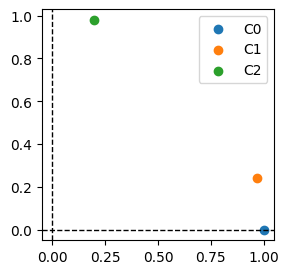

In [4]:
def ano():

    plt.figure(figsize=(3, 3))
    for i in range(3):
        w = GEN_W[i, :]
        plt.scatter(
            [w[0]],
            [w[1]],
            label=f"C{i}",
        )
    plt.axhline(0, ls="--", lw=1, color="k")
    plt.axvline(0, ls="--", lw=1, color="k")
    plt.legend()
ano()

In [5]:
def rotation_mat(theta):
    return np.array(
        [
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta), np.cos(theta)]
        ]
    )
    
rotation_mat(0)

array([[ 1., -0.],
       [ 0.,  1.]])

In [6]:
def gen_data():
    arr_x = []
    arr_y = []
    rng = np.random.default_rng(seed=1)

    arr_w = []
    for c in range(3):
        w = GEN_W[c, :]
        theta = np.arctan2(w[1], w[0])
        R = rotation_mat(-theta)
        x1 = rng.normal(scale=0.5, size=(N_PER_CLASSES,))
        x2 = rng.normal(scale=0.1, size=(N_PER_CLASSES,))
        x = np.vstack([x1, x2]).T
        x = x @ R + w*2

        arr_w.append(x.mean(axis=0))
        
        arr_x.append(x)
        arr_y.extend([c]*N_PER_CLASSES)
    arr_x = np.vstack(arr_x)
    arr_y = np.array(arr_y)

    arr_w = np.vstack(arr_w)
    
    return arr_x, arr_y, arr_w
    
X, y, W = gen_data()
W.shape

(3, 2)

(500, 2)
(500, 2)
(500, 2)


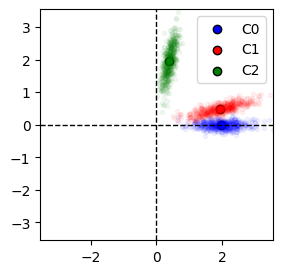

In [7]:


def ano():

    plt.figure(figsize=(3, 3))
    color= ["blue", "red", "green"]
    vmax = np.abs(X).max()
    plt.xlim([-vmax, vmax])
    plt.ylim([-vmax, vmax])
    for i in range(3):
        w = W[i, :]
        x = X[y==i, ]
        
        plt.scatter(
            [w[0]],
            [w[1]],
            label=f"C{i}",
            color=color[i],
            ec="black"
        )
        print(x.shape)
        plt.scatter(
            x[:, 0],
            x[:, 1],
            marker=".",
            color=color[i],
            alpha=0.05
        )
    plt.axhline(0, ls="--", lw=1, color="k")
    plt.axvline(0, ls="--", lw=1, color="k")
    plt.legend()
ano()

In [8]:
class MyModel(nn.Module):
    def __init__(self, W):
        super().__init__()
        self.W = torch.from_numpy(W)
        
    def forward(self, x, selected_class):
        outputs = x @ self.W.T
    
        other_classes = list(set(range(3)).difference([selected_class]))
    
        logit_pos = outputs[:, [selected_class]]
        logit_neg = outputs[:, other_classes]
    
        return torch.logsumexp(logit_pos, axis=1) - torch.logsumexp(logit_neg, axis=1)

model = MyModel(W)

In [9]:
def compute_auroc(X, y, selected_class):
    logits = model(torch.from_numpy(X), selected_class=selected_class).detach().cpu().numpy()
    y_bin = y == selected_class
    auroc = roc_auc_score(y_bin, logits)
    return auroc

compute_auroc(
    X,
    y,
    selected_class=0
)

0.99583

In [33]:
class OutputQuantity:
    def __call__(self, logits, target_logits):
        raise NotImplementedError()
    def __str__(self):
        return self.__class__.__name__
        
class LogOddWinningClass(OutputQuantity):
    def __call__(self, logits):
        return torch.sign(logits).detach() * logits

class LogOddPositiveClass(OutputQuantity):
    def __call__(self, logits):
        return logits

class LogOddWinningWeightingClass(OutputQuantity):
    def __call__(self, logits):


        is_logit_pos = (logits >= 0).int()
        
        sign = torch.sign(logits)
        factor = is_logit_pos * 2/3 + (1-is_logit_pos) *1/3
        return factor * sign * logits


def get_grad(X, selected_class):

    output_quantity = LogOddWinningClass()
    
    X = torch.from_numpy(X)
    X.requires_grad_(True)
    
    output_quantity(model(X, selected_class=selected_class)).sum().backward()

    grad = X.grad.detach().numpy()
    assert grad is not None
    return grad

GradC0 = get_grad(X, selected_class=0)

In [34]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs


class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_act
        self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class GradPCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_ctx.T @ arr_ctx
        self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCASortAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


In [35]:
class PRCAReconNonGreedyLearner:
  
    def fit(
        self, arr_act: npt.NDArray, arr_ctx: npt.NDArray, k: int,  U_init=None, device="cpu",
    ) -> npt.NDArray:
        n, d = arr_act.shape

        # assert arr_ctx.shape == arr_act.shape, arr_ctx.shape
        
        lr = 1e-4
        epochs = 5000
                
        n, d,  = arr_act.shape

        arr_act = arr_act / ((np.mean(arr_act**2) ** (1 / 2)) * (d ** (1 / 4)))
        arr_ctx = arr_ctx / ((np.mean(arr_ctx**2) ** (1 / 2)) * (d ** (1 / 4)))
        
        arr_act: torch.Tensor = torch.from_numpy(arr_act).to(device)
        arr_ctx: torch.Tensor = torch.from_numpy(arr_ctx).to(device)


        linear_layer = torch.nn.Linear(k, d, bias=False)
        trng = torch.Generator()
        trng.manual_seed(1)
        if U_init is None:
            
            U_init = torch.randn((k, d), generator=trng)
        else:
            U_init = torch.from_numpy(U_init.T)
            
        linear_layer.weight = torch.nn.Parameter(U_init)
    
        ortho_layer = torch.nn.utils.parametrizations.orthogonal(linear_layer).to(device)
        assert ortho_layer.weight.shape == (k, d)
        
        optimizer = torch.optim.Adam(ortho_layer.parameters(), lr=lr)

        pgb = tqdm(range(epochs), desc=f"{self.__class__.__name__} (k={k})")
        for epoch in pgb:
            optimizer.zero_grad()
            
            # shape: (k, d)
            U = ortho_layer.weight

            act_proj = arr_act @ U.T @ U

            residue = act_proj - arr_act

            ctx_residue = (arr_ctx * residue).sum(dim=1)
            
            # assert ctx_residue.shape == (n, 2), ctx_residue.shape
            loss = ctx_residue.pow(2)
            
            loss = loss.mean()
            
            loss.backward()
        
            optimizer.step()

            loss = loss.detach().cpu().numpy()
                
            pgb.set_description_str(f"{self.__class__.__name__} (k={k}) loss={loss:.4e}")
            
        U =  ortho_layer.weight.T.detach().cpu().numpy()
        
        # sanity_check
        np.testing.assert_allclose(U.T @ U, np.eye(k), atol=1e-4)

        return U


class PRCARecon(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        self.arr_ctx = arr_ctx
      
        self.layer = layer
        self.task_id = task_id
        self.is_slow = True
        
    def get_Uk(self, k: int):

        return PRCAReconNonGreedyLearner(
            
        ).fit(
            self.arr_act, self.arr_ctx, 
            k=k,
            U_init=PCA(
                arr_act=self.arr_act,
                arr_ctx=self.arr_ctx
            ).get_Uk(k),
            device=DEVICE
        )

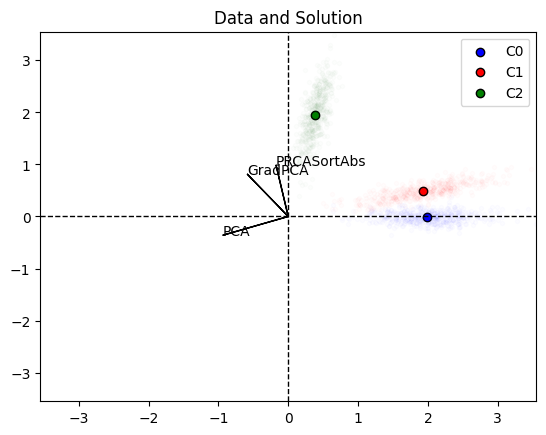

In [36]:
def viz_solution(grad_info, arr_basis_names=[PCA, GradPCA, PRCASortAbs]):

    # plt.figure(figsize=(3, 3))
    plt.title("Data and Solution")
    color= ["blue", "red", "green"]
    vmax = np.abs(X).max()
    plt.xlim([-vmax, vmax])
    plt.ylim([-vmax, vmax])
    for i in range(3):
        w = W[i, :]
        x = X[y==i, ]
        
        plt.scatter(
            [w[0]],
            [w[1]],
            label=f"C{i}",
            color=color[i],
            ec="black"
        )
        plt.scatter(
            x[:, 0],
            x[:, 1],
            marker=".",
            color=color[i],
            alpha=0.01,
        )
    plt.axhline(0, ls="--", lw=1, color="k")
    plt.axvline(0, ls="--", lw=1, color="k")

    for basis_class in arr_basis_names:
        basis_name = basis_class.__name__
        basis = basis_class(X, grad_info)
        u = basis.get_Uk(k=1)[:, 0]
        u = u
        plt.text(*u, basis_name)
        plt.arrow(
            0, 0,
            *u,
            # [u[0]],
            # [u[1]],
            # label=basis_name,
            # marker="*",
        )
    
    plt.legend()
    
viz_solution(GradC0)

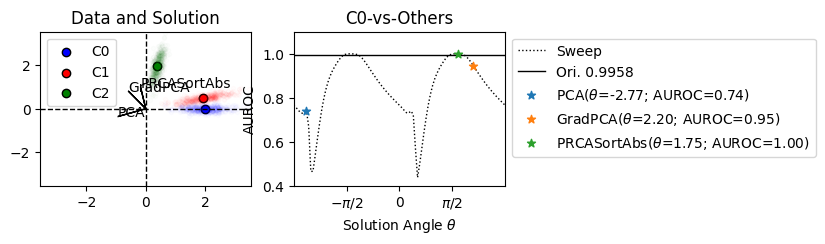

In [37]:
def viz_solution_sweep(class_ix):
    plt.figure(figsize=(3*2, 2))

    arr_basis_classes = [PCA, GradPCA, PRCASortAbs]
    

    ref_val = compute_auroc(X, y, selected_class=class_ix)
    
    grad = get_grad(X, selected_class=class_ix)

    plt.subplot(1, 2, 1)
    
    viz_solution(grad_info=grad, arr_basis_names=arr_basis_classes)
    
    plt.subplot(1, 2, 2)
    plt.title(f"C{class_ix}-vs-Others")

    plt.xlim([- np.pi, np.pi])
    plt.ylim([0.4, 1.1])


    arr_thetas = np.linspace(-np.pi, np.pi, 100)
    arr_vals = []
    for theta in arr_thetas:
        u = np.array([np.cos(theta), np.sin(theta)])
       
        uuT = np.outer(u, u)
        arr_vals.append(compute_auroc(
            X @ uuT,
            y,
            selected_class=class_ix
        ))

    plt.plot(arr_thetas, arr_vals, ls=":", color="k", lw=1, label="Sweep")

    arr_steps = [np.pi/2, 0, -np.pi/2] 
    # for s in arr_steps:
    #     plt.axvline(s, ls="-", lw=1, color="gray")
    plt.xticks(arr_steps, ["$\pi/2$", "0", "$-\pi/2$"])
    plt.axhline(ref_val, ls="-", lw=1, color="k", label=f"Ori. {ref_val:.4f}")
    for basis_class in arr_basis_classes:
        basis_name = basis_class.__name__
        basis = basis_class(X, grad)
        u = basis.get_Uk(k=1)[:, 0]
        uuT = np.outer(u, u)
        X_on_u = X @ uuT

        theta = np.arctan2(u[1], u[0])
        
        val = compute_auroc(
            X_on_u,
            y,
            selected_class=class_ix
        )

        plt.scatter([theta], [val], label=f"{basis_name}($\\theta$={theta:.2f}; AUROC={val:.2f})", marker="*", zorder=2)
    plt.legend( bbox_to_anchor=(1, 1))
    plt.ylabel("AUROC")
    plt.xlabel("Solution Angle $\\theta$")
viz_solution_sweep(class_ix=0)

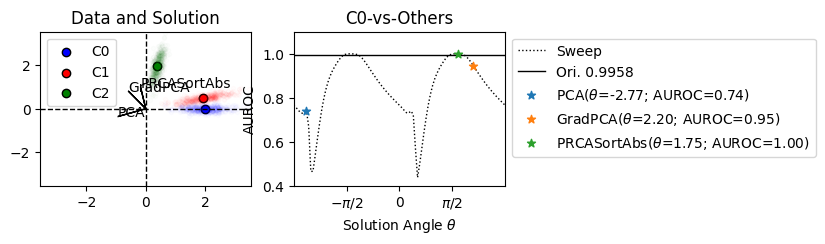

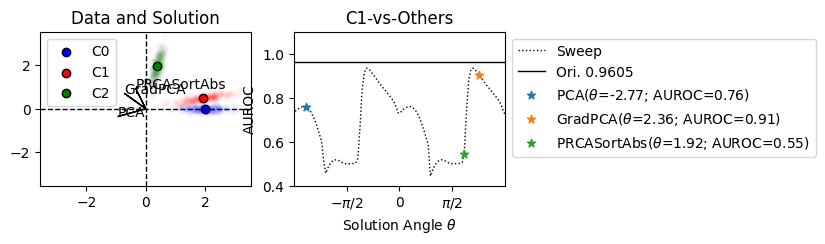

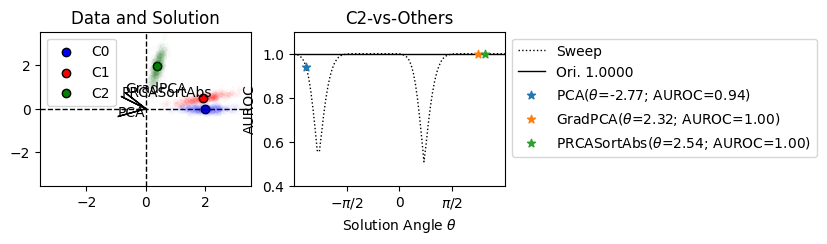

In [38]:
for cix in range(3):    
    viz_solution_sweep(class_ix=cix)
    plt.show()